# 0. Set-Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# Load data
df = pd.read_excel("DatabankWide.xlsx", sheet_name="Data")

# Focus on 2017 and 2021
years = [2017, 2021]
df = df[df["Year"].isin(years)].copy()

# --- Construct key variables ---

df["DigitalPaymentGenderGap"] = (
    df["Made or received a digital payment, male (% age 15+)"]
    - df["Made or received a digital payment, female (% age 15+)"]
)

df["MobileMoney"] = df["Mobile money account (% age 15+)"]

df["AccountOwnershipGenderGap"] = (
    df["Account, male (% age 15+)"]
    - df["Account, female (% age 15+)"]
)
df["OverallAccountGenderGap"] = df["AccountOwnershipGenderGap"]

df["ReceivedGovtPaymentsGenderGap"] = (
    df["Received government payments, male (% age 15+)"]
    - df["Received government payments, female (% age 15+)"]
)

df["PaySchoolFeesGenderGap"] = (
    df["Paid school fees, male (% age 15+)"]
    - df["Paid school fees, female (% age 15+)"]
)

df["SendReceiveRemittanceGenderGap"] = (
    df["Sent or received domestic remittances, male (% age 15+)"]
    - df["Sent or received domestic remittances, female (% age 15+)"]
)

df["AnySavingsGenderGap"] = (
    df["Saved any money, male (% age 15+)"]
    - df["Saved any money, female (% age 15+)"]
)

df["MobileMoneyGenderGap"] = (
    df["Mobile money account, male (% age 15+)"]
    - df["Mobile money account, female (% age 15+)"]
)

df["ReceiveWagesGenderGap"] = (
    df["Received wages, male (% age 15+)"]
    - df["Received wages, female (% age 15+)"]
)

df["EmergencyFund7DaysGenderGap"] = (
    df["Coming up with emergency funds in 7 days: possible, male (% age 15+)"]
    - df["Coming up with emergency funds in 7 days: possible, female (% age 15+)"]
)

df["BorrowedAnyMoneyGenderGap"] = (
    df["Borrowed any money, male (% age 15+)"]
    - df["Borrowed any money, female (% age 15+)"]
)


# 1. Global trends (“Comparing two years”)

## 1.1 Global averages by year + visual

In [2]:
global_year = (
    df.groupby("Year")[
        [
            "Made or received a digital payment, female (% age 15+)",
            "Made or received a digital payment, male (% age 15+)",
            "DigitalPaymentGenderGap",
            "Account (% age 15+)",
            "OverallAccountGenderGap",
            "MobileMoney",
        ]
    ]
    .mean()
    .reset_index()
)

global_year


,Year,"Made or received a digital payment, female (% age 15+)","Made or received a digital payment, male (% age 15+)",DigitalPaymentGenderGap,Account (% age 15+),OverallAccountGenderGap,MobileMoney
0,2017,0.499524,0.570128,0.070604,0.616977,0.070940,0.136550
1,2021,0.612454,0.678018,0.065564,0.705580,0.059771,0.227407


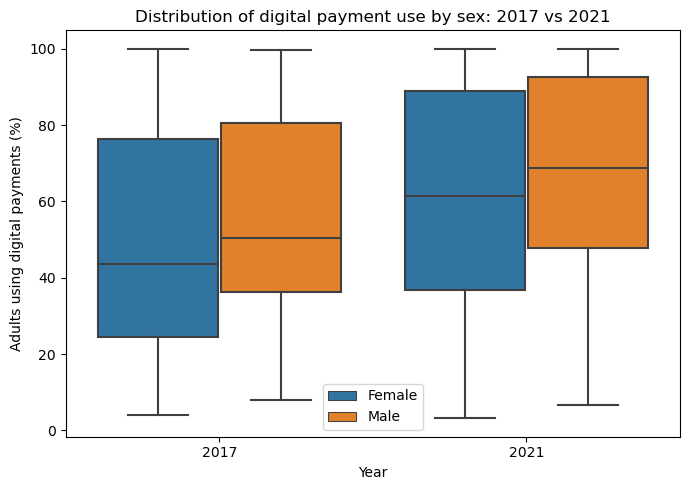

In [3]:
df_17_21 = df[df["Year"].isin([2017, 2021])].copy()

df_17_21["female_pct"] = 100 * df_17_21["Made or received a digital payment, female (% age 15+)"]
df_17_21["male_pct"]   = 100 * df_17_21["Made or received a digital payment, male (% age 15+)"]

# Make tidy / long format automatically
digpay_long = pd.melt(
    df_17_21,
    id_vars="Year",
    value_vars=["female_pct", "male_pct"],
    var_name="Sex",
    value_name="DigitalPaymentUse"
)

digpay_long["Sex"] = digpay_long["Sex"].map({
    "female_pct": "Female",
    "male_pct": "Male"
})

# --- Plot ---
plt.figure(figsize=(7,5))
sns.boxplot(
    data=digpay_long,
    x="Year",
    y="DigitalPaymentUse",
    hue="Sex"
)

plt.ylabel("Adults using digital payments (%)")
plt.title("Distribution of digital payment use by sex: 2017 vs 2021")
plt.legend(title="")
plt.tight_layout()
plt.show()


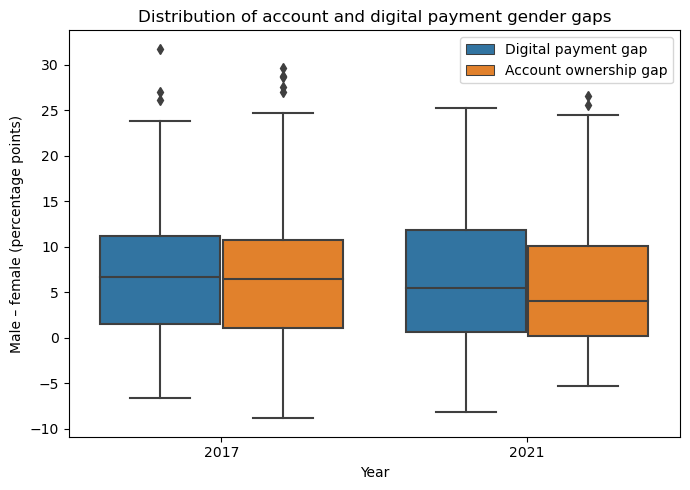

In [4]:

df_17_21 = df[df["Year"].isin([2017, 2021])].copy()

df_17_21["dig_gap_pct"] = 100 * df_17_21["DigitalPaymentGenderGap"]
df_17_21["acc_gap_pct"] = 100 * df_17_21["OverallAccountGenderGap"]

# Make tidy / long format
gap_long = pd.melt(
    df_17_21,
    id_vars="Year",
    value_vars=["dig_gap_pct", "acc_gap_pct"],
    var_name="GapType",
    value_name="GapValue"
)

gap_long["GapType"] = gap_long["GapType"].map({
    "dig_gap_pct": "Digital payment gap",
    "acc_gap_pct": "Account ownership gap"
})

# --- Plot ---
plt.figure(figsize=(7,5))
sns.boxplot(
    data=gap_long,
    x="Year",
    y="GapValue",
    hue="GapType"
)

plt.ylabel("Male – female (percentage points)")
plt.title("Distribution of account and digital payment gender gaps")
plt.legend(title="")
plt.tight_layout()
plt.show()


Between 2017 and 2021, the global share of adults using digital payments increased for both men and women. Women’s usage rose slightly faster, so both the account and digital payment gender gaps narrowed a little, but they remain sizeable.

# 2. Regional comparisons

## 2.1 Build region–year summary table

In [5]:
region_year = (
    df.groupby(["Region", "Year"])
    .agg(
        n_countries=("Country name", "nunique"),
        account=("Account (% age 15+)", "mean"),
        anydigital=("Made or received a digital payment (% age 15+)", "mean"),
        dig_gap=("DigitalPaymentGenderGap", "mean"),
        acc_gap=("OverallAccountGenderGap", "mean"),
        mobile_money=("Mobile money account (% age 15+)", "mean"),
    )
    .reset_index()
)

region_year


,Region,Year,n_countries,account,anydigital,dig_gap,acc_gap,mobile_money
0,East Asia & Pacific (excluding high income),2017,11,0.546076,0.419030,0.012457,-0.000308,0.066384
1,East Asia & Pacific (excluding high income),2021,10,0.673532,0.598888,0.037414,0.023820,0.249711
2,Europe & Central Asia (excluding high income),2017,22,0.570763,0.507823,0.055121,0.052705,0.057333
3,Europe & Central Asia (excluding high income),2021,18,0.685776,0.622790,0.059683,0.058818,0.151954
4,High income,2017,46,0.915544,0.872466,0.036381,0.029689,0.165169
5,High income,2021,42,0.956469,0.934930,0.015456,0.010676,0.219311
6,Latin America & Caribbean (excluding high income),2017,18,0.488990,0.397668,0.080875,0.078949,0.065907
7,Latin America & Caribbean (excluding high income),2021,16,0.597177,0.504627,0.086972,0.080486,0.191583
8,Middle East & North Africa (excluding high inc...,2017,11,0.435558,0.317001,0.141458,0.174744,0.059717
9,Middle East & North Africa (excluding high inc...,2021,10,0.410875,0.322258,0.134718,0.149531,0.061140


## 2.2 Region-level change

In [6]:
region_change = region_year.pivot(
    index="Region",
    columns="Year",
    values=["anydigital", "account", "mobile_money", "dig_gap"]
)

region_change["anydigital_change"] = (
    region_change["anydigital", 2021] - region_change["anydigital", 2017]
)
region_change["mobile_money_change"] = (
    region_change["mobile_money", 2021] - region_change["mobile_money", 2017]
)
region_change["dig_gap_change"] = (
    region_change["dig_gap", 2021] - region_change["dig_gap", 2017]
)
region_change["account_change"] = (
    region_change["account", 2021] - region_change["account", 2017]
)

region_change[["dig_gap_change", "anydigital_change", "account_change"]]


,dig_gap_change,anydigital_change,account_change
Year,,,
Region,,,
East Asia & Pacific (excluding high income),0.024958,0.179858,0.127456
Europe & Central Asia (excluding high income),0.004561,0.114967,0.115013
High income,-0.020925,0.062464,0.040925
Latin America & Caribbean (excluding high income),0.006097,0.106959,0.108187
Middle East & North Africa (excluding high income),-0.006741,0.005258,-0.024683
South Asia,-0.004703,0.005594,-0.011067
Sub-Saharan Africa (excluding high income),0.007982,0.149640,0.119374


## 2.3 Figure 3 – Digital payments by region and sex (2021)

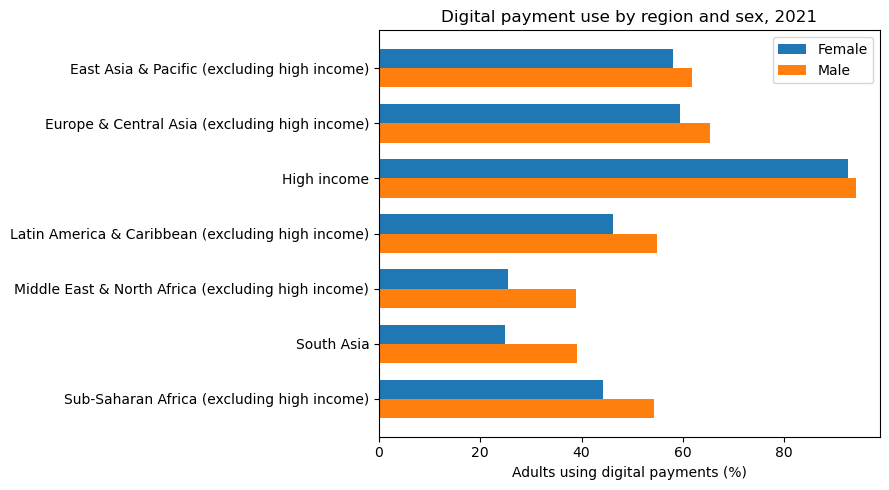

In [7]:
df_2021 = df[df["Year"] == 2021].copy()

region_sex_2021 = (
    df_2021.groupby("Region")[
        [
            "Made or received a digital payment, female (% age 15+)",
            "Made or received a digital payment, male (% age 15+)",
        ]
    ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9,5))

regions = region_sex_2021["Region"]
y = np.arange(len(regions))
width = 0.35

female = 100 * region_sex_2021["Made or received a digital payment, female (% age 15+)"]
male   = 100 * region_sex_2021["Made or received a digital payment, male (% age 15+)"]

ax.barh(y - width/2, female, width, label="Female")
ax.barh(y + width/2, male,   width, label="Male")

ax.set_yticks(y)
ax.set_yticklabels(regions)
ax.invert_yaxis()
ax.set_xlabel("Adults using digital payments (%)")
ax.set_title("Digital payment use by region and sex, 2021")
ax.legend()
plt.tight_layout()
plt.show()


## 2.4 Figure 4 – Digital gender gap by region, 2017 vs 2021

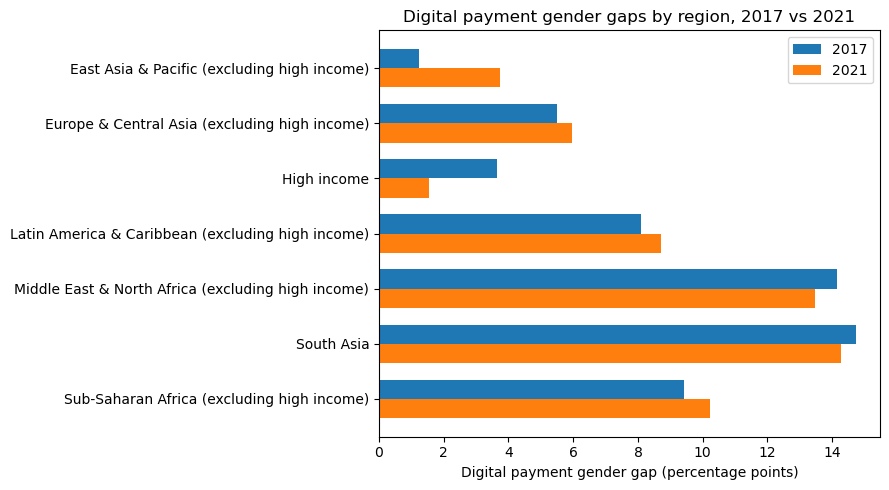

In [8]:
region_gap = region_year.pivot(index="Region", columns="Year", values="dig_gap").reset_index()

fig, ax = plt.subplots(figsize=(9,5))

regions = region_gap["Region"]
y = np.arange(len(regions))
width = 0.35

gap17 = 100 * region_gap[2017]
gap21 = 100 * region_gap[2021]

ax.barh(y - width/2, gap17, width, label="2017")
ax.barh(y + width/2, gap21, width, label="2021")

ax.set_yticks(y)
ax.set_yticklabels(regions)
ax.invert_yaxis()
ax.set_xlabel("Digital payment gender gap (percentage points)")
ax.set_title("Digital payment gender gaps by region, 2017 vs 2021")
ax.legend()
plt.tight_layout()
plt.show()


High-income economies show very small gender gaps, while South Asia and MENA have the largest and most persistent gaps. Other regions sit between these extremes.

# 3. Where do gaps come from? (scatterplots)

## 3.1 Figure 5 – Digital vs account gender gaps (country level, 2021)

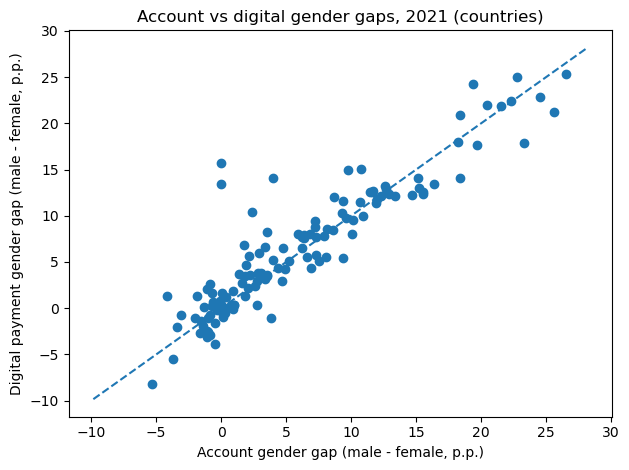

In [9]:
scatter_df = df_2021[
    ["Country name", "Region", "DigitalPaymentGenderGap", "OverallAccountGenderGap"]
].dropna()

fig, ax = plt.subplots()

ax.scatter(100*scatter_df["OverallAccountGenderGap"],
           100*scatter_df["DigitalPaymentGenderGap"])

ax.set_xlabel("Account gender gap (male - female, p.p.)")
ax.set_ylabel("Digital payment gender gap (male - female, p.p.)")
ax.set_title("Account vs digital gender gaps, 2021 (countries)")

# 45-degree line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, linestyle="--")
plt.tight_layout()
plt.show()


## 3.2 Figure 6 – Digital vs mobile-money gender gaps

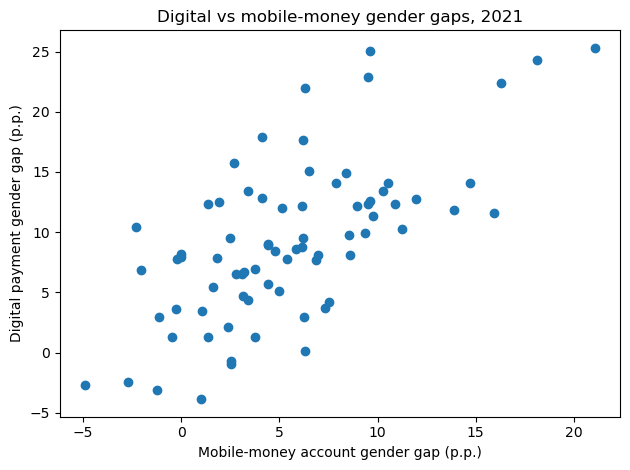

In [10]:
scatter_df2 = df_2021[
    ["DigitalPaymentGenderGap", "MobileMoneyGenderGap"]
].dropna()

fig, ax = plt.subplots()

ax.scatter(100*scatter_df2["MobileMoneyGenderGap"],
           100*scatter_df2["DigitalPaymentGenderGap"])

ax.set_xlabel("Mobile-money account gender gap (p.p.)")
ax.set_ylabel("Digital payment gender gap (p.p.)")
ax.set_title("Digital vs mobile-money gender gaps, 2021")
plt.tight_layout()
plt.show()


Countries with large gaps in basic account ownership and mobile-money accounts almost always have large digital payment gender gaps. Points cluster close to the 45-degree line in Figure 5, showing how strongly the digital gap tracks the account gap.

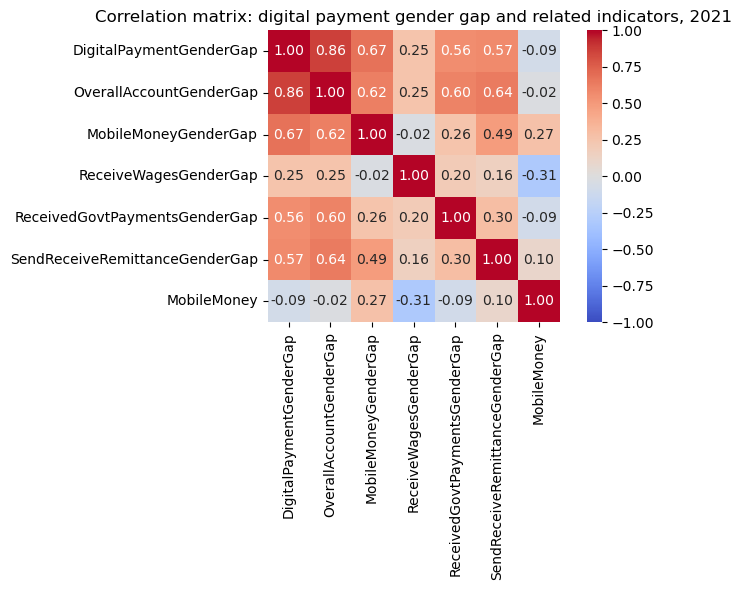

In [11]:
corr_vars = [
    "DigitalPaymentGenderGap",
    "OverallAccountGenderGap",
    "MobileMoneyGenderGap",
    "ReceiveWagesGenderGap",
    "ReceivedGovtPaymentsGenderGap",
    "SendReceiveRemittanceGenderGap",
    "MobileMoney",  # level, not a gap
]

corr_df = df_2021[corr_vars].dropna()

# Compute correlation matrix
corr_matrix = corr_df.corr()

# --- Plot correlation heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
)
plt.title("Correlation matrix: digital payment gender gap and related indicators, 2021")
plt.tight_layout()
plt.show()


In [12]:
# import scipy.stats
# scipy.stats.pearsonr(df["MobileMoney"], df["DigitalPaymentGenderGap"])[0]
corr_account = df_2021['DigitalPaymentGenderGap'].corr(df_2021['OverallAccountGenderGap'])
corr_mobile = df_2021['DigitalPaymentGenderGap'].corr(df_2021['MobileMoneyGenderGap'])

print(f"Correlation with Account Gender Gap: {corr_account:.2f}")
print(f"Correlation with Mobile Money Account Gender Gap: {corr_mobile:.2f}")

Correlation with Account Gender Gap: 0.92
Correlation with Mobile Money Account Gender Gap: 0.66


# 4. Has the gap widened or narrowed?

## 4.1 Figure 7 – Country change in digital gender gaps, 2017–2021

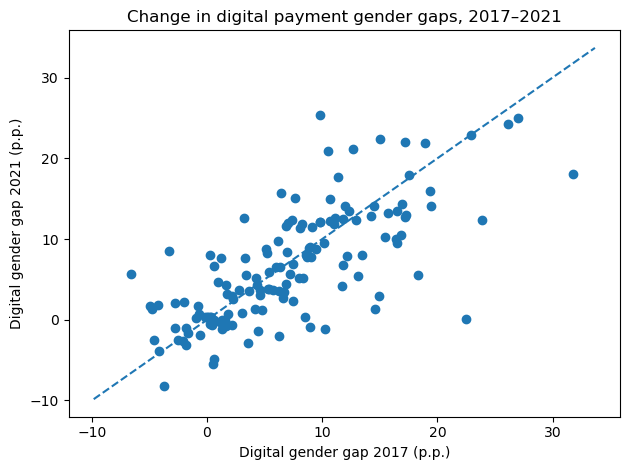

In [13]:
both = df.pivot_table(
    index="Country name",
    columns="Year",
    values="DigitalPaymentGenderGap"
).dropna()

fig, ax = plt.subplots()

ax.scatter(100*both[2017], 100*both[2021])

ax.set_xlabel("Digital gender gap 2017 (p.p.)")
ax.set_ylabel("Digital gender gap 2021 (p.p.)")
ax.set_title("Change in digital payment gender gaps, 2017–2021")

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, linestyle="--")
plt.tight_layout()
plt.show()


## Top Improvers/Worseners

In [14]:
both["gap_change"] = 100 * (both[2021] - both[2017])

print("Biggest reductions (most improvement):")
print(both.sort_values("gap_change").head(10)["gap_change"])

print("\nBiggest increases (gap widened):")
print(both.sort_values("gap_change", ascending=False).head(10)["gap_change"])


Biggest reductions (most improvement):
Country name
United Arab Emirates   -22.390068
Saudi Arabia           -13.753521
Uganda                 -13.263524
Lebanon                -12.799656
Mali                   -11.925891
Pakistan               -11.580596
Panama                 -11.352196
Tajikistan              -9.895533
Uruguay                 -8.253336
Chile                   -8.116180
Name: gap_change, dtype: float64

Biggest increases (gap widened):
Country name
Cote d'Ivoire             15.478048
Taiwan, China             12.313318
Philippines               11.827809
Bosnia and Herzegovina    10.380128
Uzbekistan                 9.399998
Sri Lanka                  9.241694
Algeria                    8.495909
Thailand                   7.824898
Bolivia                    7.442141
Mozambique                 7.410029
Name: gap_change, dtype: float64


# 5. Regression models (drivers of the gap)

## 5.1 Model 1 – financial-behavior gaps

In [15]:
df_2021 = df[df["Year"] == 2021].copy()

features_model = [
    "OverallAccountGenderGap",
    "MobileMoneyGenderGap",
    "ReceivedGovtPaymentsGenderGap",
    "ReceiveWagesGenderGap",
    "AnySavingsGenderGap",
    "BorrowedAnyMoneyGenderGap",
    "SendReceiveRemittanceGenderGap",
    "EmergencyFund7DaysGenderGap",
    "MobileMoney",   # overall level
]

model_df = df_2021[["DigitalPaymentGenderGap"] + features_model].dropna()

X = sm.add_constant(model_df[features_model])
y = model_df["DigitalPaymentGenderGap"]

model1 = sm.OLS(y, X).fit()
print(model1.summary())


                               OLS Regression Results                              
Dep. Variable:     DigitalPaymentGenderGap   R-squared:                       0.811
Model:                                 OLS   Adj. R-squared:                  0.783
Method:                      Least Squares   F-statistic:                     29.48
Date:                     Thu, 04 Dec 2025   Prob (F-statistic):           3.56e-19
Time:                             11:07:24   Log-Likelihood:                 154.05
No. Observations:                       72   AIC:                            -288.1
Df Residuals:                           62   BIC:                            -265.3
Df Model:                                9                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

R² ≈ 0.81 → variables explain ~80% of variation.

OverallAccountGenderGap and MobileMoneyGenderGap have the largest, highly significant coefficients.

Most other gaps become insignificant once account/mobile-money gaps are included.

## 5.2 Model 2 – adding structural factors

In [16]:
df_2021["IncomeGroupLevel"] = df_2021["Income group"].map({
    "Low income": 1,
    "Lower middle income": 2,
    "Upper middle income": 3,
    "High income": 4,
})

features2 = [
    "OverallAccountGenderGap",
    "MobileMoneyGenderGap",
    "MobileMoney",
    "Own a mobile phone (% age 15+)",
    "IncomeGroupLevel",
]

model2_df = df_2021[["DigitalPaymentGenderGap"] + features2].dropna()

X2 = sm.add_constant(model2_df[features2])
y2 = model2_df["DigitalPaymentGenderGap"]

model2 = sm.OLS(y2, X2).fit()
print(model2.summary())


                               OLS Regression Results                              
Dep. Variable:     DigitalPaymentGenderGap   R-squared:                       0.817
Model:                                 OLS   Adj. R-squared:                  0.802
Method:                      Least Squares   F-statistic:                     52.79
Date:                     Thu, 04 Dec 2025   Prob (F-statistic):           1.59e-20
Time:                             11:07:24   Log-Likelihood:                 136.65
No. Observations:                       65   AIC:                            -261.3
Df Residuals:                           59   BIC:                            -248.3
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

R² ≈ 0.82 (very similar).

Account gender gap and mobile-money gender gap remain the dominant drivers.

Higher overall mobile-money use is linked to a smaller digital gender gap (negative coefficient).

Phone ownership and income group add little once those gaps are controlled for.

In [17]:
import pandas as pd
 
# Keep only 2021

df_2021 = df[df["Year"] == 2021].copy()
 
# Variables for the summary table

summary_vars = [

    "Made or received a digital payment, female (% age 15+)",

    "Made or received a digital payment, male (% age 15+)",

    "DigitalPaymentGenderGap",

    "Account, female (% age 15+)",

    "Account, male (% age 15+)",

    "OverallAccountGenderGap",

    "Mobile money account (% age 15+)",   # MobileMoney level

    "MobileMoneyGenderGap",

    "Own a mobile phone (% age 15+)",     # PhoneOwnership

]
 
summary_df = (

    df_2021[summary_vars]

    .describe()

    .T[["mean", "std", "min", "max"]]

)
 
summary_df.index.name = "Variable"
 
# rounding for nicer display

summary_df_rounded = summary_df.round(3)
 
summary_df_rounded


,mean,std,min,max
Variable,,,,
"Made or received a digital payment, female (% age 15+)",0.612,0.287,0.032,1.000
"Made or received a digital payment, male (% age 15+)",0.678,0.250,0.066,1.000
DigitalPaymentGenderGap,0.066,0.070,-0.082,0.253
"Account, female (% age 15+)",0.676,0.266,0.042,1.000
"Account, male (% age 15+)",0.736,0.227,0.077,1.000
OverallAccountGenderGap,0.060,0.071,-0.053,0.266
Mobile money account (% age 15+),0.227,0.169,0.000,0.687
MobileMoneyGenderGap,0.055,0.050,-0.049,0.211
Own a mobile phone (% age 15+),0.877,0.118,0.322,1.000


In [18]:
import statsmodels.api as sm
 
# Create model dataset for 2021
df_2021 = df[df["Year"] == 2021].copy()
 
df_2021["IncomeGroupLevel"] = df_2021["Income group"].map({
    "Low income": 1,
    "Lower middle income": 2,
    "Upper middle income": 3,
    "High income": 4,
})
 
model_df = df_2021[
    [
        "Country name",
        "DigitalPaymentGenderGap",
        "OverallAccountGenderGap",
        "MobileMoneyGenderGap",
        "Mobile money account (% age 15+)",
        "Own a mobile phone (% age 15+)",
        "IncomeGroupLevel",
    ]
].dropna()
 
X = model_df[
    [
        "OverallAccountGenderGap",
        "MobileMoneyGenderGap",
        "Mobile money account (% age 15+)",
        "Own a mobile phone (% age 15+)",
        "IncomeGroupLevel",
    ]
]
y = model_df["DigitalPaymentGenderGap"]
 
X_const = sm.add_constant(X)
 
model = sm.OLS(y, X_const).fit()
 
# Clean coefficient table
coef_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std. Error": model.bse,
    "t-stat": model.tvalues,
    "p-value": model.pvalues,
})
 
coef_table_rounded = coef_table.round(4)
 
coef_table_rounded

,Coefficient,Std. Error,t-stat,p-value
const,-0.0243,0.0269,-0.9046,0.3694
OverallAccountGenderGap,0.6568,0.0724,9.0771,0.0000
MobileMoneyGenderGap,0.3822,0.1083,3.5281,0.0008
Mobile money account (% age 15+),-0.0564,0.0236,-2.3907,0.0200
Own a mobile phone (% age 15+),0.0750,0.0409,1.8338,0.0717
IncomeGroupLevel,-0.0036,0.0073,-0.4939,0.6232


In [19]:
# saving the model's fitted values in variable 'fitted'
fitted = model.fittedvalues
# calculating model residuals
residuals = df_2021["DigitalPaymentGenderGap"] - fitted
print(residuals)

3     -0.009480
7           NaN
11          NaN
17     0.012063
21     0.012044
         ...   
642         NaN
645         NaN
649         NaN
653         NaN
657         NaN
Length: 145, dtype: float64


In [20]:
# using '.resid' to find the model residuals
residuals = model.resid
print(residuals)

3     -0.009480
17     0.012063
21     0.012044
40     0.034983
52    -0.038613
         ...   
524   -0.002874
532   -0.043550
560   -0.013948
567   -0.008725
571   -0.002302
Length: 65, dtype: float64


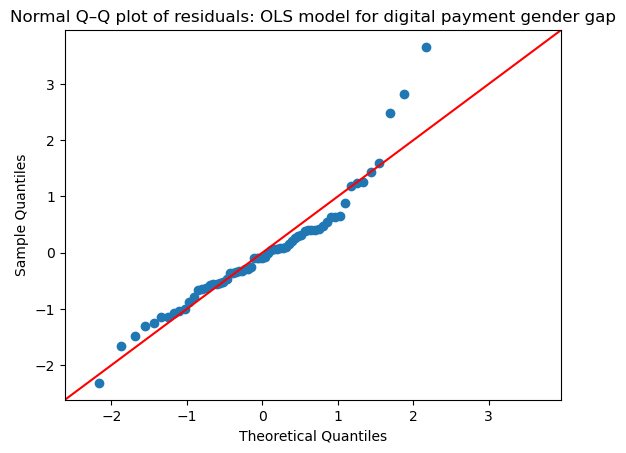

In [21]:
# importing 'qqplot
from statsmodels.api import qqplot
# making a qqplot for the model residuals
qqplot(data=model.resid, fit=True, line="45")
plt.title("Normal Q–Q plot of residuals: OLS model for digital payment gender gap")
plt.show()

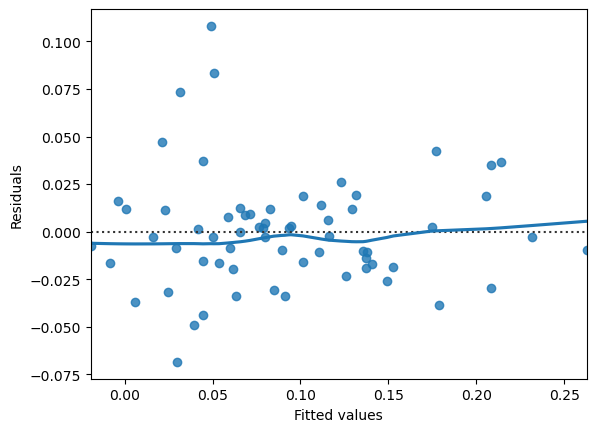

In [22]:
#plotting fitted values (predictions) of the model against the model's residuals
sns.residplot(data=df_2021, x=model.fittedvalues, y=model.resid, lowess=True)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

